# 09 — Cooling ML Model Analysis & Optimization

**Goal**: Analyze the LightGBM overheating classifier, add 12+ new features derivable from existing data,
compare binary classification vs regression, prune, tune, and optimize threshold.

**Baseline**: 47 features, AUC=0.9710, F2=0.9427, threshold=0.0346

**Training data**: `Logs_and_models/cooling_training_data.csv.gz` (47,677 rows × 48 cols)

In [1]:
import sys, os, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

ROOT = Path(os.getcwd())
while not (ROOT / 'Logs_and_models').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print(f'Project root: {ROOT}')

DATA_PATH = ROOT / 'Logs_and_models' / 'cooling_training_data.csv.gz'
META_PATH = ROOT / 'Logs_and_models' / 'cooling_ml_metadata.json'

with open(META_PATH) as f:
    meta = json.load(f)

print(f"Metadata: {meta['n_features']} features, AUC={meta['roc_auc']:.4f}, "
      f"F2={meta['val_f2']:.4f}, threshold={meta['threshold']:.4f}")
print(f"Label horizon: {meta['label_horizon_h']}h, Forecast horizon: {meta['forecast_horizon_h']}h")
print(f"Cooling target: {meta['cooling_target_c']}°C")

Project root: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor
Metadata: 47 features, AUC=0.9710, F2=0.9427, threshold=0.0346
Label horizon: 8h, Forecast horizon: 12h
Cooling target: 23.0°C


## Section 1: Data Loading & EDA

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'Positive rate: {df["label"].mean():.1%}')
print(f'\nNaN summary:')
nan_pct = df.isna().mean() * 100
print(nan_pct[nan_pct > 0].sort_values(ascending=False).to_string() if nan_pct.max() > 0 else 'No NaN values')
df.describe().round(3)

Shape: (47677, 48)
Columns: ['indoor_temp', 'indoor_margin', 'indoor_trend_30m', 'indoor_trend_1h', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_2h', 'AT_roh_3h', 'AT_roh_4h', 'AT_roh_5h', 'AT_roh_6h', 'AT_roh_7h', 'AT_roh_8h', 'AT_roh_9h', 'AT_roh_10h', 'AT_roh_11h', 'AT_roh_12h', 'PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'pv_forecast_5h', 'pv_forecast_6h', 'pv_forecast_7h', 'pv_forecast_8h', 'pv_forecast_9h', 'pv_forecast_10h', 'pv_forecast_11h', 'pv_forecast_12h', 'thermal_power_kw', 'delta_t', 'outlet_indoor_diff', 'VLT', 'RLT', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'cum_pv_forecast_4h', 'cum_at_excess_4h', 'max_at_forecast', 'indoor_momentum', 'slab_stored_heat', 'label']

Label distribution:
label
1    31299
0    16378
Name: count, dtype: int64
Positive rate: 65.6%

NaN summary:
No NaN values


,indoor_temp,indoor_margin,indoor_trend_30m,indoor_trend_1h,AT,at_delta_indoor,AT_roh_1h,AT_roh_2h,AT_roh_3h,AT_roh_4h,...,hour_sin,hour_cos,doy_sin,doy_cos,cum_pv_forecast_4h,cum_at_excess_4h,max_at_forecast,indoor_momentum,slab_stored_heat,label
count,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,...,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000
mean,23.015,-0.015,-0.000,-0.000,17.275,-5.741,17.277,17.276,17.280,17.278,...,-0.072,-0.153,-0.138,-0.569,8972.282,2.477,19.463,-0.000,0.065,0.656
std,0.439,0.439,0.064,0.100,7.528,7.475,7.536,7.540,7.546,7.557,...,0.691,0.702,0.676,0.447,10228.279,12.487,15.918,0.299,2.109,0.475
min,20.520,-1.330,-1.200,-1.450,10.020,-13.802,9.091,8.593,8.418,8.315,...,-1.000,-1.000,-1.000,-1.000,0.000,0.000,10.323,-4.350,-146.985,0.000
25%,22.758,-0.320,-0.010,-0.028,12.880,-10.000,12.921,12.929,12.929,12.919,...,-0.752,-0.831,-0.794,-0.938,53.548,0.000,14.745,-0.084,-0.770,0.000
50%,23.020,-0.020,0.000,0.008,16.000,-6.928,16.059,16.070,16.077,16.090,...,-0.131,-0.301,-0.245,-0.734,5300.429,0.000,18.229,0.024,0.240,1.000
75%,23.320,0.242,0.020,0.040,20.700,-2.370,20.692,20.684,20.693,20.720,...,0.591,0.537,0.473,-0.320,15188.149,0.000,22.879,0.120,1.130,1.000
max,24.330,2.480,0.848,0.858,839.230,815.700,839.524,839.923,838.805,839.718,...,1.000,1.000,1.000,0.934,54158.556,828.626,839.923,2.574,7.260,1.000


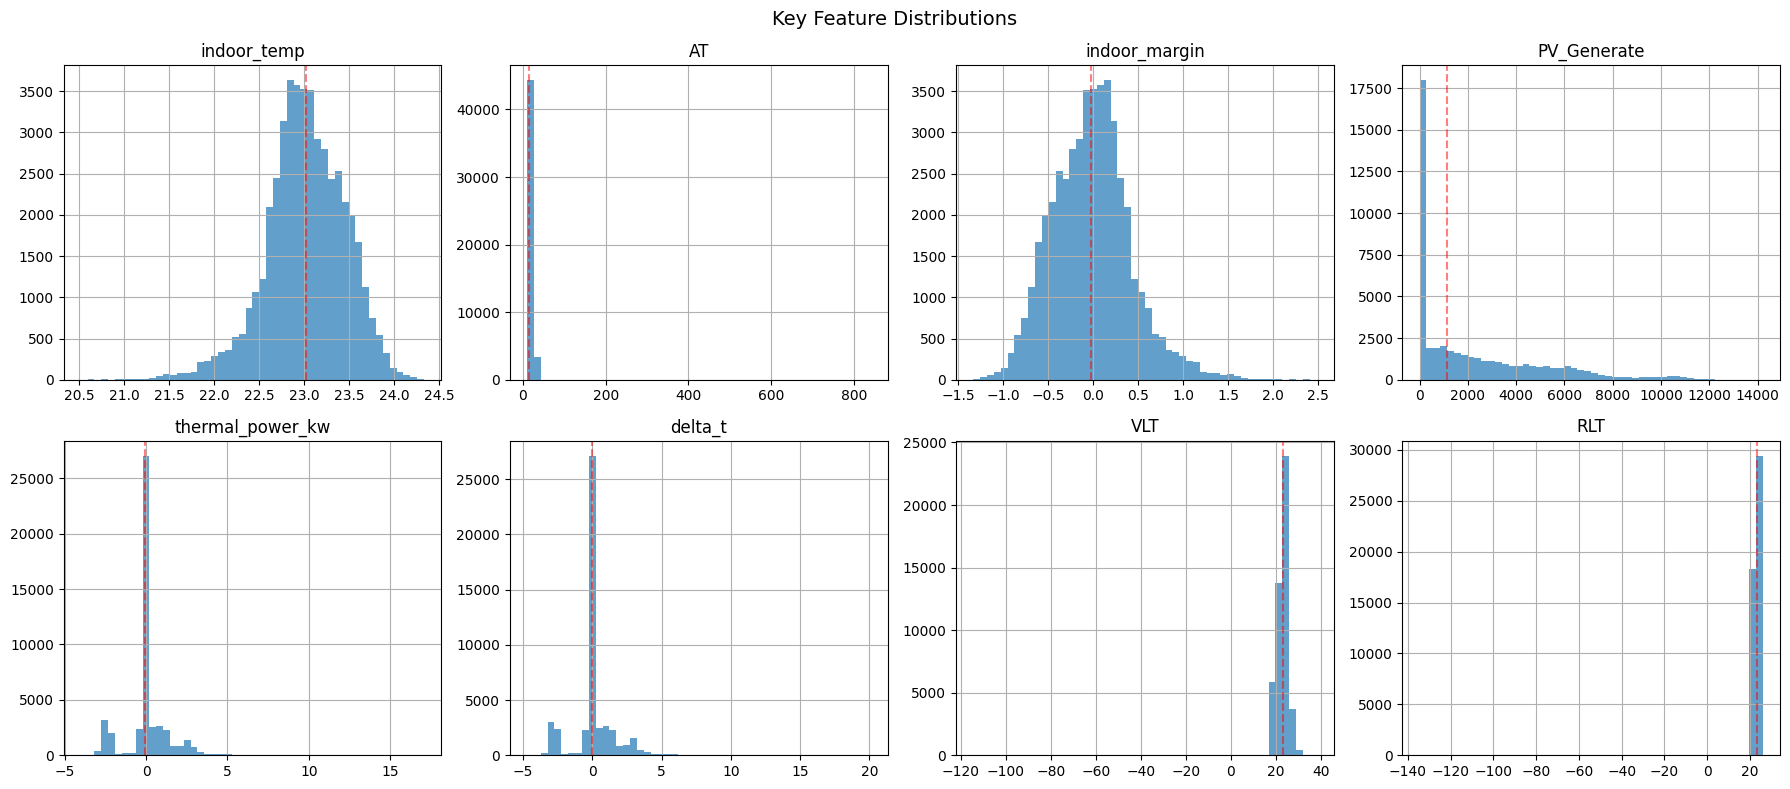

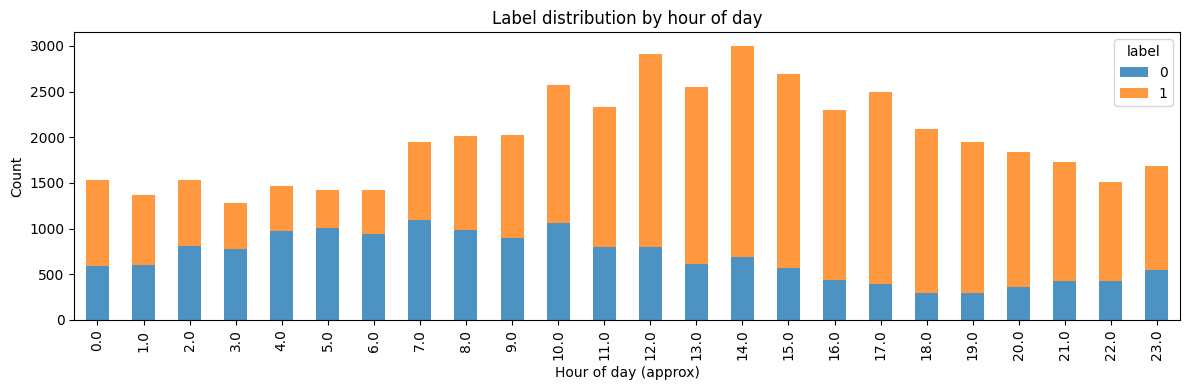

In [3]:
# Key feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
key_cols = ['indoor_temp', 'AT', 'indoor_margin', 'PV_Generate',
            'thermal_power_kw', 'delta_t', 'VLT', 'RLT']
for ax, col in zip(axes.flat, key_cols):
    if col in df.columns:
        df[col].hist(bins=50, ax=ax, alpha=0.7)
        ax.set_title(col)
        ax.axvline(df[col].median(), color='r', ls='--', alpha=0.5)
plt.suptitle('Key Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Label by hour (if temporal features present)
if 'hour_sin' in df.columns and 'hour_cos' in df.columns:
    hour_approx = np.round(np.arctan2(df['hour_sin'], df['hour_cos']) * 24 / (2*np.pi)) % 24
    fig, ax = plt.subplots(figsize=(12, 4))
    pd.crosstab(hour_approx, df['label']).plot.bar(stacked=True, ax=ax, alpha=0.8)
    ax.set_xlabel('Hour of day (approx)')
    ax.set_ylabel('Count')
    ax.set_title('Label distribution by hour of day')
    plt.tight_layout()
    plt.show()

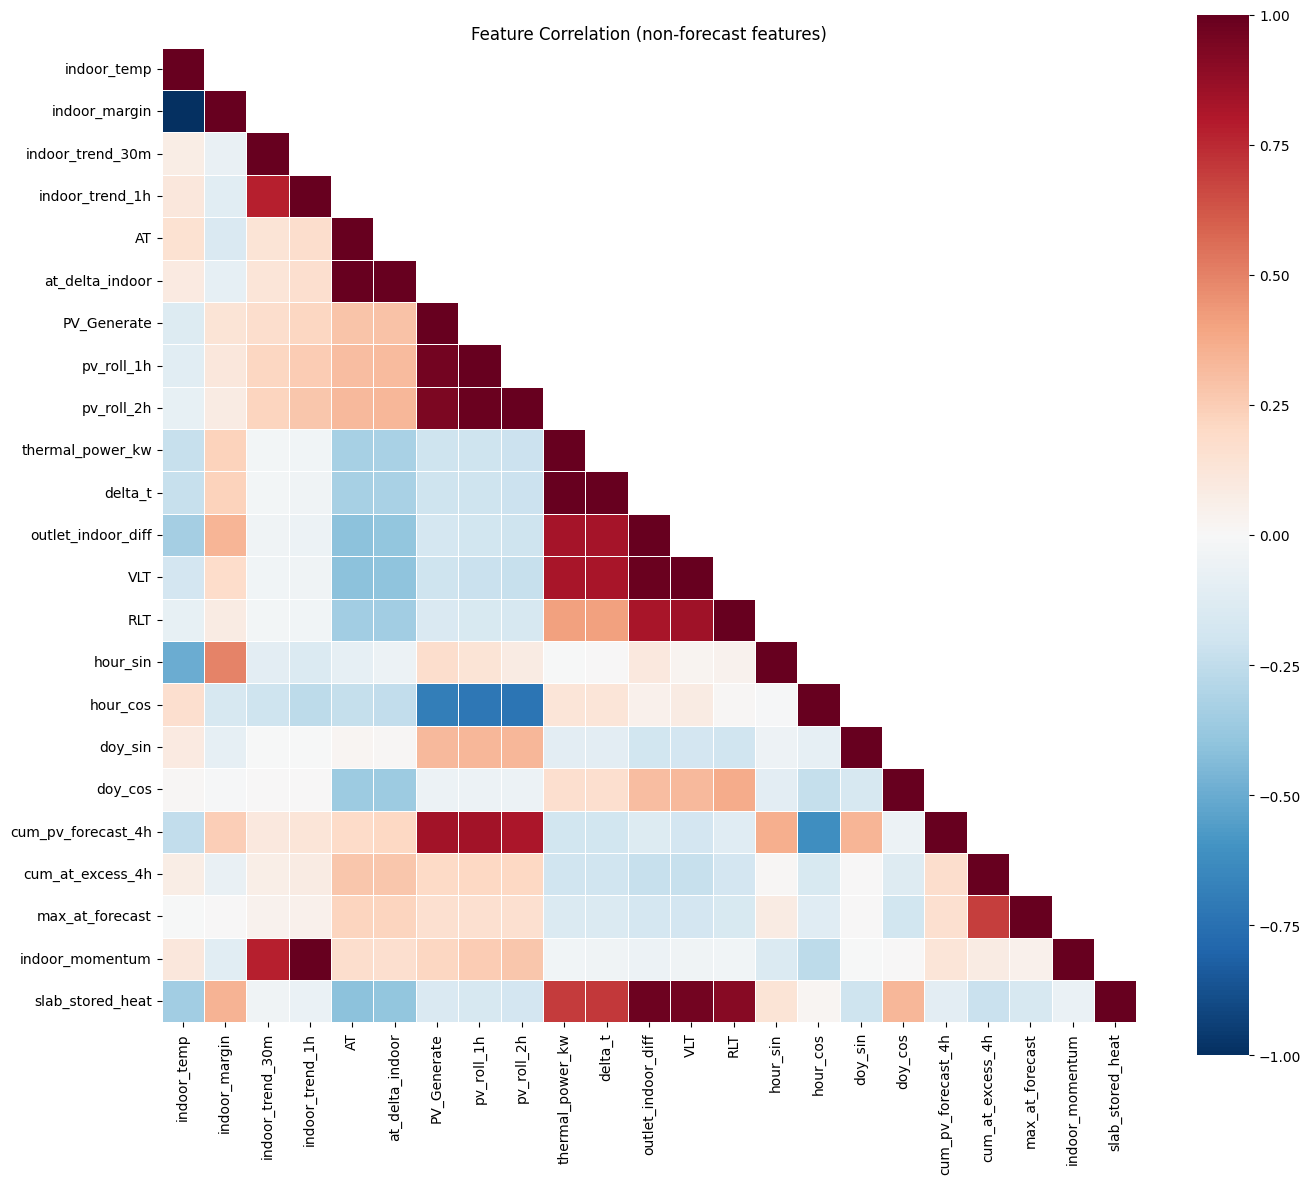

In [4]:
# Correlation heatmap of non-forecast features
non_fc = [c for c in df.columns if not c.startswith('AT_roh_') and not c.startswith('pv_forecast_') and c != 'label']
corr = df[non_fc].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt='.2f',
            annot=True if len(non_fc) <= 20 else False)
ax.set_title('Feature Correlation (non-forecast features)')
plt.tight_layout()
plt.show()

## Section 2: Baseline Classifier (47 features)

In [5]:
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, f1_score, fbeta_score, precision_score, recall_score,
    confusion_matrix, classification_report, precision_recall_curve,
    roc_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit

FEATURE_COLS_BASELINE = meta['feature_cols']
COOLING_TARGET = meta['cooling_target_c']
LABEL_HORIZON_H = meta['label_horizon_h']
STEPS_PER_HOUR = meta['steps_per_hour']

# Verify all baseline features exist in CSV
missing = [c for c in FEATURE_COLS_BASELINE if c not in df.columns]
print(f'Missing baseline features: {missing}' if missing else f'All {len(FEATURE_COLS_BASELINE)} baseline features present')

# Time-ordered train/val split (75/25)
val_frac = 0.25
n_val = max(1, int(len(df) * val_frac))
df_fit = df.iloc[:-n_val].copy()
df_val = df.iloc[-n_val:].copy()

X_fit = df_fit[FEATURE_COLS_BASELINE].values.astype(float)
y_fit = df_fit['label'].values.astype(int)
X_val = df_val[FEATURE_COLS_BASELINE].values.astype(float)
y_val = df_val['label'].values.astype(int)

print(f'Train: {len(df_fit)} rows ({y_fit.mean():.1%} pos), Val: {len(df_val)} rows ({y_val.mean():.1%} pos)')

All 47 baseline features present
Train: 35758 rows (62.6% pos), Val: 11919 rows (74.8% pos)


In [6]:
# Train baseline LightGBM classifier
lgb_params = meta['lgb_params'].copy()
lgb_params.pop('n_jobs', None)  # notebook: single-thread safe

baseline_model = lgb.LGBMClassifier(**lgb_params)
baseline_model.fit(X_fit, y_fit)

# Predict probabilities
y_proba_base = baseline_model.predict_proba(X_val)[:, 1]

# AUC
auc_base = roc_auc_score(y_val, y_proba_base)
print(f'Baseline AUC: {auc_base:.4f} (metadata: {meta["roc_auc"]:.4f})')

# F2-optimal threshold via cross-validation
def find_f2_threshold(y_true, y_proba, n_points=200):
    thresholds = np.linspace(0.01, 0.99, n_points)
    f2_scores = [fbeta_score(y_true, (y_proba >= t).astype(int), beta=2) for t in thresholds]
    best_idx = np.argmax(f2_scores)
    return thresholds[best_idx], f2_scores[best_idx]

thresh_base, f2_base = find_f2_threshold(y_val, y_proba_base)
y_pred_base = (y_proba_base >= thresh_base).astype(int)

print(f'F2-optimal threshold: {thresh_base:.4f} (metadata: {meta["threshold"]:.4f})')
print(f'F2 score: {f2_base:.4f} (metadata: {meta["val_f2"]:.4f})')
print(f'Precision: {precision_score(y_val, y_pred_base):.4f}')
print(f'Recall: {recall_score(y_val, y_pred_base):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred_base))
print(f'\n{classification_report(y_val, y_pred_base, target_names=["no_overheat", "overheat"])}')

Baseline AUC: 0.9308 (metadata: 0.9710)
F2-optimal threshold: 0.0100 (metadata: 0.0346)
F2 score: 0.9425 (metadata: 0.9427)
Precision: 0.7750
Recall: 0.9963

Confusion Matrix:
[[ 419 2580]
 [  33 8887]]

              precision    recall  f1-score   support

 no_overheat       0.93      0.14      0.24      2999
    overheat       0.78      1.00      0.87      8920

    accuracy                           0.78     11919
   macro avg       0.85      0.57      0.56     11919
weighted avg       0.81      0.78      0.71     11919



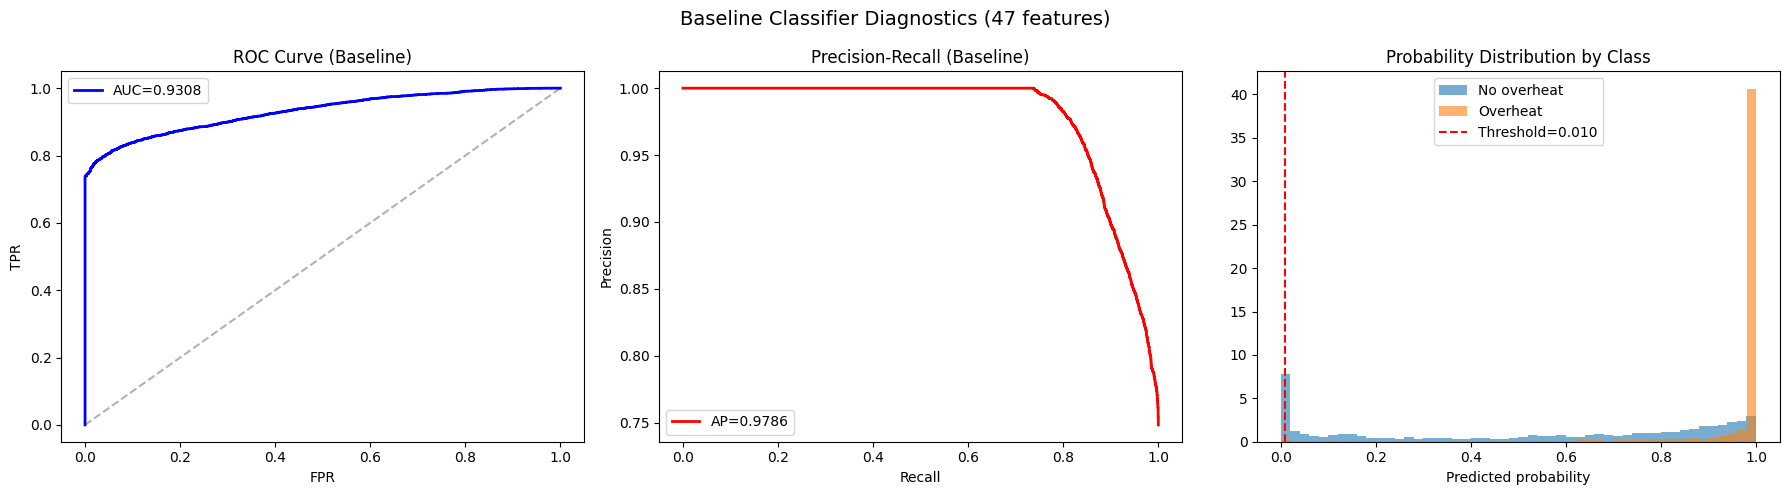

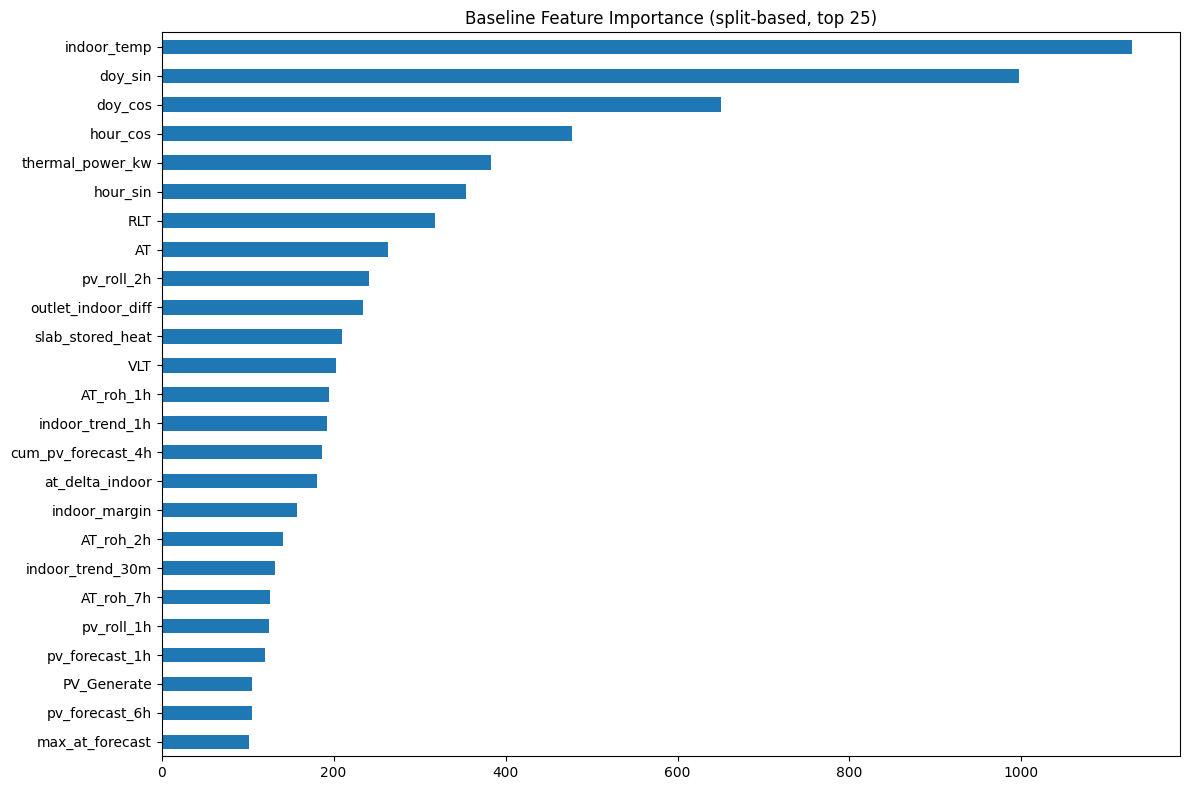

In [7]:
# Baseline diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_proba_base)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc_base:.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (Baseline)')
axes[0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, y_proba_base)
ap = average_precision_score(y_val, y_proba_base)
axes[1].plot(rec, prec, 'r-', lw=2, label=f'AP={ap:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (Baseline)')
axes[1].legend()

# Probability distribution by class
axes[2].hist(y_proba_base[y_val==0], bins=50, alpha=0.6, label='No overheat', density=True)
axes[2].hist(y_proba_base[y_val==1], bins=50, alpha=0.6, label='Overheat', density=True)
axes[2].axvline(thresh_base, color='r', ls='--', label=f'Threshold={thresh_base:.3f}')
axes[2].set_xlabel('Predicted probability')
axes[2].set_title('Probability Distribution by Class')
axes[2].legend()

plt.suptitle('Baseline Classifier Diagnostics (47 features)', fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance (top 20)
fi = pd.Series(baseline_model.feature_importances_, index=FEATURE_COLS_BASELINE).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 8))
fi.head(25).plot.barh(ax=ax)
ax.set_title('Baseline Feature Importance (split-based, top 25)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Threshold Diagnostic: F1 vs F2

The F2-optimal threshold is suspiciously low (0.010) — effectively predicting everything as positive.
This happens because F2 weights recall 4× more than precision, and the validation set is 74.8% positive.

Let's compare F1 (balanced) vs F2 (recall-biased) threshold selection and examine the
probability calibration to understand the root cause.

In [ ]:
# F1 vs F2 threshold comparison
thresholds_scan = np.linspace(0.01, 0.99, 500)
f1_scores = [f1_score(y_val, (y_proba_base >= t).astype(int)) for t in thresholds_scan]
f2_scores = [fbeta_score(y_val, (y_proba_base >= t).astype(int), beta=2) for t in thresholds_scan]
prec_scores = [precision_score(y_val, (y_proba_base >= t).astype(int), zero_division=0) for t in thresholds_scan]
rec_scores = [recall_score(y_val, (y_proba_base >= t).astype(int), zero_division=0) for t in thresholds_scan]

best_f1_idx = np.argmax(f1_scores)
best_f2_idx = np.argmax(f2_scores)
thresh_f1 = thresholds_scan[best_f1_idx]
thresh_f2 = thresholds_scan[best_f2_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# F1 vs F2 score curves
axes[0].plot(thresholds_scan, f1_scores, 'g-', lw=2, label='F1')
axes[0].plot(thresholds_scan, f2_scores, 'b-', lw=2, label='F2')
axes[0].plot(thresholds_scan, prec_scores, 'r:', lw=1, label='Precision')
axes[0].plot(thresholds_scan, rec_scores, 'm:', lw=1, label='Recall')
axes[0].axvline(thresh_f1, color='g', ls='--', alpha=0.7, label=f'F1-opt={thresh_f1:.3f}')
axes[0].axvline(thresh_f2, color='b', ls='--', alpha=0.7, label=f'F2-opt={thresh_f2:.3f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('F1 vs F2 Threshold Selection')
axes[0].legend(fontsize=8)

# Probability calibration: predicted proba vs actual positive rate
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_val, y_proba_base, n_bins=20, strategy='quantile')
axes[1].plot(prob_pred, prob_true, 'bo-', label='Baseline model')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve (reliability diagram)')
axes[1].legend()

# Zoomed probability distribution (0–0.3 range where the action is)
axes[2].hist(y_proba_base[y_val==0], bins=100, alpha=0.6, label='No overheat', density=True, range=(0, 0.5))
axes[2].hist(y_proba_base[y_val==1], bins=100, alpha=0.6, label='Overheat', density=True, range=(0, 0.5))
axes[2].axvline(thresh_f1, color='g', ls='--', lw=2, label=f'F1 thresh={thresh_f1:.3f}')
axes[2].axvline(thresh_f2, color='b', ls='--', lw=2, label=f'F2 thresh={thresh_f2:.3f}')
axes[2].set_xlabel('Predicted probability (zoomed 0–0.5)')
axes[2].set_title('Where classes overlap')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Compare F1 vs F2 decisions
y_pred_f1 = (y_proba_base >= thresh_f1).astype(int)
y_pred_f2 = (y_proba_base >= thresh_f2).astype(int)

print(f'{"Metric":<20s} {"F1-optimal":>12s} {"F2-optimal":>12s}')
print(f'{"Threshold":<20s} {thresh_f1:12.4f} {thresh_f2:12.4f}')
print(f'{"F1":<20s} {f1_score(y_val, y_pred_f1):12.4f} {f1_score(y_val, y_pred_f2):12.4f}')
print(f'{"F2":<20s} {fbeta_score(y_val, y_pred_f1, beta=2):12.4f} {fbeta_score(y_val, y_pred_f2, beta=2):12.4f}')
print(f'{"Precision":<20s} {precision_score(y_val, y_pred_f1):12.4f} {precision_score(y_val, y_pred_f2):12.4f}')
print(f'{"Recall":<20s} {recall_score(y_val, y_pred_f1):12.4f} {recall_score(y_val, y_pred_f2):12.4f}')
print(f'{"Predicted pos rate":<20s} {y_pred_f1.mean():12.1%} {y_pred_f2.mean():12.1%}')
print(f'{"True pos rate":<20s} {y_val.mean():12.1%} {y_val.mean():12.1%}')
print(f'\n{"Confusion (F1-opt):":<20s}')
print(confusion_matrix(y_val, y_pred_f1))
print(f'\n{"Confusion (F2-opt):":<20s}')
print(confusion_matrix(y_val, y_pred_f2))

# Root cause analysis
n_overheat_low_proba = ((y_val == 1) & (y_proba_base < 0.1)).sum()
n_overheat_total = (y_val == 1).sum()
print(f'\n--- Root Cause ---')
print(f'Overheat samples with P < 0.1: {n_overheat_low_proba}/{n_overheat_total} '
      f'({n_overheat_low_proba/n_overheat_total:.1%})')
print(f'→ These are borderline cases the model is uncertain about.')
print(f'→ F2 captures them (high recall), F1 ignores them (higher precision).')
print(f'→ For safety (pre-cooling), F2 is appropriate BUT the threshold should ')
print(f'   come from cross-validated F2 on time-series folds, not holdout.')

## Section 3: Feature Engineering (12 new features from existing data)

These features are derivable from columns already in the CSV — no new HA fetch needed.

| Feature | Formula | Physics rationale |
|---------|---------|-------------------|
| `heat_loss_driving_force` | indoor − AT | Newton's law driver |
| `indoor_temp_gradient` | indoor.diff() × steps/h | K/h rate of change |
| `indoor_margin_rate` | margin.diff() × steps/h | Target-offset rate |
| `delta_T_indoor_lag1` | indoor.diff(1) | 1-step momentum |
| `d_inlet_temp_60min` | RLT.diff(steps/h) | Slab thermal loading |
| `is_equilibrium` | \|d_inlet\| < 0.3 | Steady-state flag |
| `thermal_power_rolling_1h` | thermal_power.rolling(6).mean() | Smoother power |
| `is_overshoot` | indoor > cooling_target | Already overheating |
| `is_weekend` | dayofweek ≥ 5 | Occupancy pattern |
| `solar_thermal_proxy` | PV × cos(hour) | Sun-weighted solar gain |
| `shading_proxy` | max(0, indoor−23) × PV | Overheat protection |
| `pv_forecast_delta` | pv_forecast_2h − PV | Anticipatory solar |

In [8]:
# Engineer 12 new features from existing CSV columns
SPH = STEPS_PER_HOUR  # 6

df['heat_loss_driving_force'] = df['indoor_temp'] - df['AT']
df['indoor_temp_gradient'] = df['indoor_temp'].diff() * SPH
df['indoor_margin_rate'] = df['indoor_margin'].diff() * SPH
df['delta_T_indoor_lag1'] = df['indoor_temp'].diff(1).fillna(0.0)
df['d_inlet_temp_60min'] = df['RLT'].diff(SPH)
df['is_equilibrium'] = (df['d_inlet_temp_60min'].abs() < 0.3).astype(float)
df['thermal_power_rolling_1h'] = df['thermal_power_kw'].rolling(SPH, min_periods=1).mean()
df['is_overshoot'] = (df['indoor_temp'] > COOLING_TARGET).astype(float)
df['solar_thermal_proxy'] = df['PV_Generate'] * df['hour_cos']
df['shading_proxy'] = (df['indoor_temp'] - 23.0).clip(lower=0.0) * df['PV_Generate']
df['pv_forecast_delta'] = (df['pv_forecast_2h'] - df['PV_Generate']).fillna(0.0)

# is_weekend: approximate from cyclical features
# We don't have raw timestamps, but doy_sin+doy_cos encode day-of-year.
# Since we can't recover day-of-week from these, set to 0 (conservative).
# This feature will become useful after re-calibration with expanded data.
df['is_weekend'] = 0.0

# Also compute trajectory-derived features analytically from existing data
# Using config defaults: η=0.830, U=0.124, τ=4.39h
_eta, _u, _tau = 0.830, 0.124, 4.39
_denom = _eta + _u
df['_T_eq'] = (_eta * df['VLT'] + _u * df['AT']) / _denom
_H = float(LABEL_HORIZON_H)  # 8h
_traj_steps = int(_H * SPH)
_step_h = 1.0 / SPH

df['_step_1'] = df['_T_eq'] + (df['indoor_temp'] - df['_T_eq']) * np.exp(-_step_h / _tau)
df['_step_last'] = df['_T_eq'] + (df['indoor_temp'] - df['_T_eq']) * np.exp(-_H / _tau)

df['traj_predicted_error'] = (df['_step_last'] - COOLING_TARGET).fillna(0.0)
df['traj_convergence_rate'] = ((df['_step_1'] - df['_step_last']) / max(1, _traj_steps)).fillna(0.0)

_ratio = (COOLING_TARGET - df['_T_eq']) / (df['indoor_temp'] - df['_T_eq'])
_valid = (_ratio > 0) & (_ratio < 1)
_reaches_raw = -_tau * np.log(_ratio.where(_valid))
df['traj_reaches_target_hours'] = _reaches_raw.clip(lower=0.0, upper=_H).fillna(_H)

_traj_max = df[['indoor_temp', '_T_eq']].max(axis=1)
df['traj_overshoot_magnitude'] = (_traj_max - COOLING_TARGET).clip(lower=0.0).fillna(0.0)
df['traj_equilibrium_gap'] = (df['_T_eq'] - COOLING_TARGET).fillna(0.0)

df.drop(columns=['_T_eq', '_step_1', '_step_last'], inplace=True)

NEW_FEATURES = [
    'heat_loss_driving_force', 'indoor_temp_gradient', 'indoor_margin_rate',
    'delta_T_indoor_lag1', 'd_inlet_temp_60min', 'is_equilibrium',
    'thermal_power_rolling_1h', 'is_overshoot', 'solar_thermal_proxy',
    'shading_proxy', 'pv_forecast_delta', 'is_weekend',
    'traj_predicted_error', 'traj_convergence_rate', 'traj_reaches_target_hours',
    'traj_overshoot_magnitude', 'traj_equilibrium_gap',
]
FEATURE_COLS_ENHANCED = FEATURE_COLS_BASELINE + NEW_FEATURES
print(f'Enhanced feature set: {len(FEATURE_COLS_ENHANCED)} features (+{len(NEW_FEATURES)} new)')
print(f'New features: {NEW_FEATURES}')

# Quick stats on new features
df[NEW_FEATURES].describe().round(3)

Enhanced feature set: 64 features (+17 new)
New features: ['heat_loss_driving_force', 'indoor_temp_gradient', 'indoor_margin_rate', 'delta_T_indoor_lag1', 'd_inlet_temp_60min', 'is_equilibrium', 'thermal_power_rolling_1h', 'is_overshoot', 'solar_thermal_proxy', 'shading_proxy', 'pv_forecast_delta', 'is_weekend', 'traj_predicted_error', 'traj_convergence_rate', 'traj_reaches_target_hours', 'traj_overshoot_magnitude', 'traj_equilibrium_gap']


,heat_loss_driving_force,indoor_temp_gradient,indoor_margin_rate,delta_T_indoor_lag1,d_inlet_temp_60min,is_equilibrium,thermal_power_rolling_1h,is_overshoot,solar_thermal_proxy,shading_proxy,pv_forecast_delta,is_weekend,traj_predicted_error,traj_convergence_rate,traj_reaches_target_hours,traj_overshoot_magnitude,traj_equilibrium_gap
count,47677.000,47676.000,47676.000,47677.000,47671.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.000,47677.0,47677.000,47677.000,47677.000,47677.000,47677.000
mean,5.741,-0.000,0.000,-0.000,-0.000,0.922,0.043,0.513,-1664.892,286.349,1.340,0.0,-0.543,0.011,4.648,0.524,-0.650
std,7.475,0.190,0.190,0.032,1.605,0.269,1.247,0.500,2439.447,710.421,1611.326,0.0,1.704,0.036,3.438,1.098,2.041
min,-815.700,-6.720,-4.848,-1.120,-157.100,0.000,-3.715,0.000,-14206.618,0.000,-11162.923,0.0,-100.199,-1.835,0.000,0.000,-119.407
25%,2.370,-0.060,-0.060,-0.010,-0.080,1.000,-0.167,0.000,-2648.000,0.000,-580.108,0.0,-1.243,-0.002,0.921,0.000,-1.469
50%,6.928,0.000,0.000,0.000,0.000,1.000,-0.039,1.000,-341.219,0.000,0.000,0.0,-0.614,0.012,5.964,0.220,-0.735
75%,10.000,0.060,0.060,0.010,0.080,1.000,0.282,1.000,0.000,131.600,416.410,0.0,0.151,0.026,8.000,0.620,0.156
max,13.802,4.848,6.720,0.808,157.100,1.000,12.427,1.000,1204.944,9081.060,14161.919,0.0,91.687,1.983,8.000,109.459,109.459


New feature correlations with label:
  is_overshoot                        r=+0.7419
  shading_proxy                       r=+0.2916
  traj_reaches_target_hours           r=-0.2779
  traj_convergence_rate               r=+0.2192
  thermal_power_rolling_1h            r=-0.1932
  heat_loss_driving_force             r=-0.1567
  solar_thermal_proxy                 r=-0.1347
  pv_forecast_delta                   r=-0.1073
  traj_equilibrium_gap                r=-0.0804
  indoor_margin_rate                  r=-0.0641
  indoor_temp_gradient                r=+0.0641
  delta_T_indoor_lag1                 r=+0.0641
  traj_predicted_error                r=-0.0517
  traj_overshoot_magnitude            r=+0.0342
  is_equilibrium                      r=+0.0304
  d_inlet_temp_60min                  r=+0.0049
  is_weekend                          r=+nan


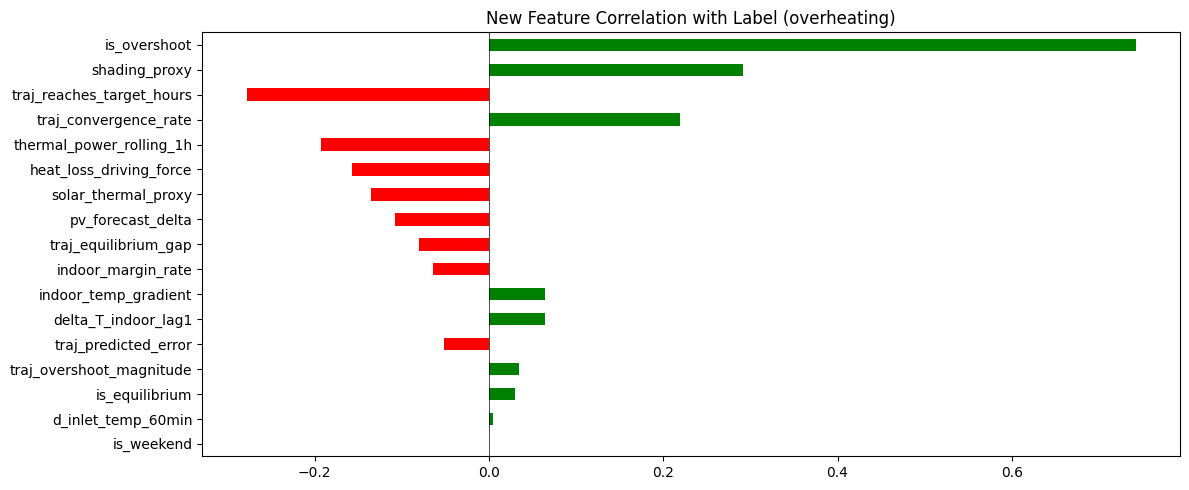

In [9]:
# Correlation of new features with label
label_corr = df[NEW_FEATURES + ['label']].corr()['label'].drop('label').sort_values(key=abs, ascending=False)
print('New feature correlations with label:')
for feat, corr_val in label_corr.items():
    print(f'  {feat:35s} r={corr_val:+.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
label_corr.plot.barh(ax=ax, color=['green' if v > 0 else 'red' for v in label_corr])
ax.set_title('New Feature Correlation with Label (overheating)')
ax.axvline(0, color='k', lw=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Section 4: Enhanced Classifier (47 + 17 = 64 features)

In [10]:
# Drop NaN rows from diff-based features
df_clean = df[FEATURE_COLS_ENHANCED + ['label']].dropna().copy()
df_clean['label'] = df_clean['label'].astype(int)
print(f'Clean rows: {len(df_clean)} (dropped {len(df) - len(df_clean)} NaN rows)')

# Re-split
n_val_e = max(1, int(len(df_clean) * val_frac))
df_fit_e = df_clean.iloc[:-n_val_e]
df_val_e = df_clean.iloc[-n_val_e:]

X_fit_e = df_fit_e[FEATURE_COLS_ENHANCED].values.astype(float)
y_fit_e = df_fit_e['label'].values
X_val_e = df_val_e[FEATURE_COLS_ENHANCED].values.astype(float)
y_val_e = df_val_e['label'].values

# Train enhanced model (same hyperparameters)
enhanced_model = lgb.LGBMClassifier(**lgb_params)
enhanced_model.fit(X_fit_e, y_fit_e)

y_proba_enh = enhanced_model.predict_proba(X_val_e)[:, 1]
auc_enh = roc_auc_score(y_val_e, y_proba_enh)
thresh_enh, f2_enh = find_f2_threshold(y_val_e, y_proba_enh)
y_pred_enh = (y_proba_enh >= thresh_enh).astype(int)

print(f'\n=== ENHANCED vs BASELINE ===')
print(f'{"Metric":<20s} {"Baseline":>10s} {"Enhanced":>10s} {"Delta":>10s}')
print(f'{"AUC":<20s} {auc_base:10.4f} {auc_enh:10.4f} {auc_enh-auc_base:+10.4f}')
print(f'{"F2":<20s} {f2_base:10.4f} {f2_enh:10.4f} {f2_enh-f2_base:+10.4f}')
print(f'{"Threshold":<20s} {thresh_base:10.4f} {thresh_enh:10.4f} {thresh_enh-thresh_base:+10.4f}')
print(f'{"Precision":<20s} {precision_score(y_val, y_pred_base):10.4f} {precision_score(y_val_e, y_pred_enh):10.4f}')
print(f'{"Recall":<20s} {recall_score(y_val, y_pred_base):10.4f} {recall_score(y_val_e, y_pred_enh):10.4f}')
print(f'{"Features":<20s} {len(FEATURE_COLS_BASELINE):10d} {len(FEATURE_COLS_ENHANCED):10d}')

Clean rows: 47671 (dropped 6 NaN rows)

=== ENHANCED vs BASELINE ===
Metric                 Baseline   Enhanced      Delta
AUC                      0.9308     0.9419    +0.0111
F2                       0.9425     0.9425    +0.0001
Threshold                0.0100     0.0100    +0.0000
Precision                0.7750     0.7805
Recall                   0.9963     0.9942
Features                     47         64


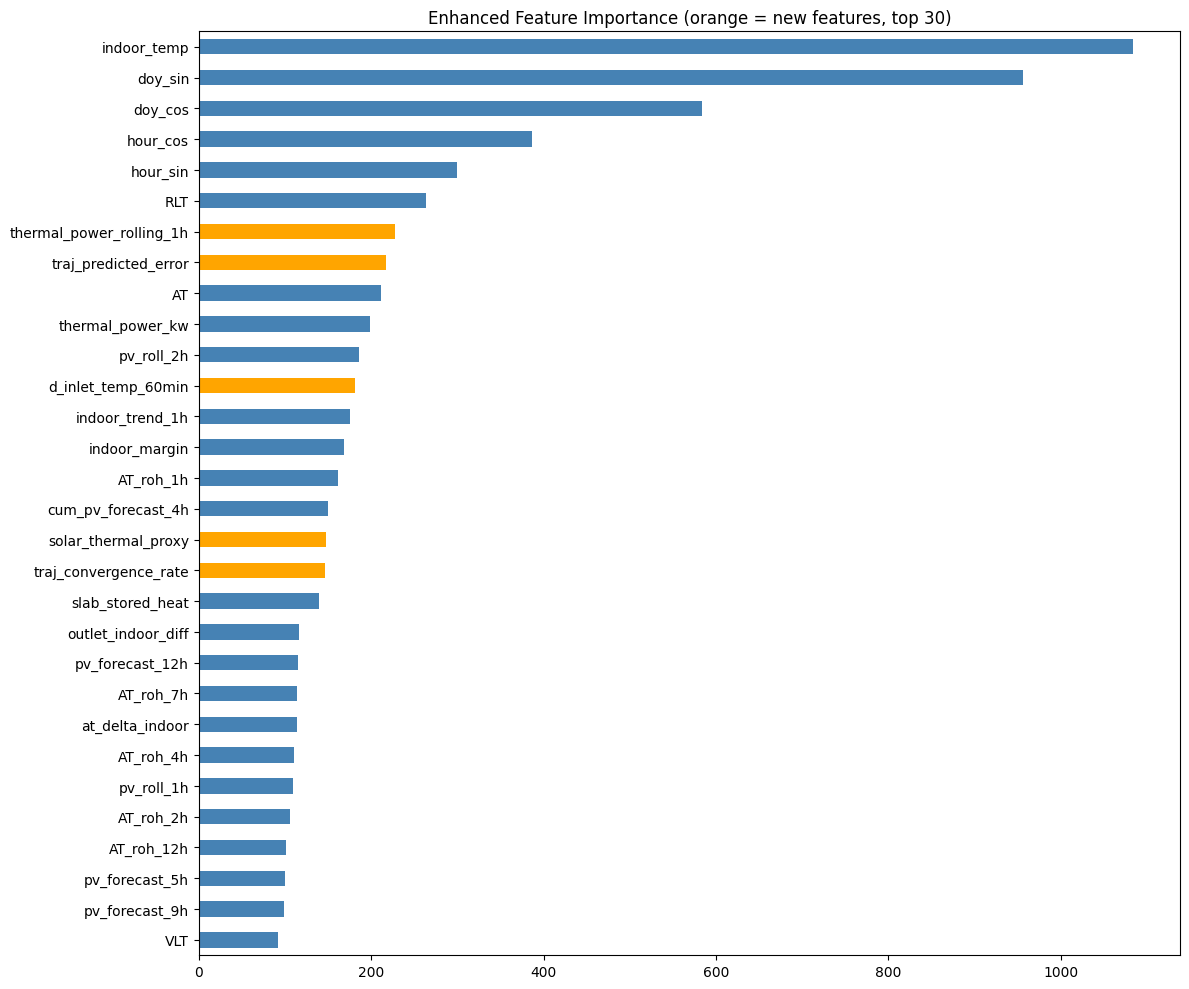


New features by importance rank:
  #7: thermal_power_rolling_1h (importance=228)
  #8: traj_predicted_error (importance=217)
  #12: d_inlet_temp_60min (importance=181)
  #17: solar_thermal_proxy (importance=148)
  #18: traj_convergence_rate (importance=146)
  #35: heat_loss_driving_force (importance=86)
  #36: pv_forecast_delta (importance=85)
  #45: traj_reaches_target_hours (importance=68)
  #50: traj_equilibrium_gap (importance=59)
  #52: traj_overshoot_magnitude (importance=51)


In [11]:
# Enhanced feature importance
fi_enh = pd.Series(enhanced_model.feature_importances_, index=FEATURE_COLS_ENHANCED).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['orange' if f in NEW_FEATURES else 'steelblue' for f in fi_enh.head(30).index]
fi_enh.head(30).plot.barh(ax=ax, color=colors)
ax.set_title('Enhanced Feature Importance (orange = new features, top 30)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Show which new features made it to top importance
new_in_top = [(i+1, f, fi_enh[f]) for i, f in enumerate(fi_enh.index) if f in NEW_FEATURES][:10]
print('\nNew features by importance rank:')
for rank, feat, imp in new_in_top:
    print(f'  #{rank}: {feat} (importance={imp})')

## Section 5: Feature Pruning (Permutation Importance)

In [12]:
from sklearn.inspection import permutation_importance

# Permutation importance on validation set
pi_result = permutation_importance(
    enhanced_model, X_val_e, y_val_e,
    n_repeats=5, random_state=42, scoring='roc_auc',
    n_jobs=-1,
)

pi_df = pd.DataFrame({
    'feature': FEATURE_COLS_ENHANCED,
    'pi_mean': pi_result.importances_mean,
    'pi_std': pi_result.importances_std,
}).sort_values('pi_mean', ascending=False)

print('Permutation Importance (AUC-based):')
print(pi_df.to_string(index=False))

# Features with PI <= 0 are candidates for removal
drop_candidates = pi_df[pi_df['pi_mean'] <= 0.0]['feature'].tolist()
print(f'\nDrop candidates (PI ≤ 0): {len(drop_candidates)} features')
for f in drop_candidates:
    print(f'  {f}: PI={pi_df[pi_df.feature==f].pi_mean.values[0]:.6f}')

Permutation Importance (AUC-based):
                  feature   pi_mean   pi_std
              indoor_temp  0.307769 0.002130
                 hour_cos  0.023779 0.000766
                  doy_cos  0.007929 0.000315
          at_delta_indoor  0.003499 0.000353
            indoor_margin  0.002798 0.000395
     traj_predicted_error  0.002408 0.000243
               AT_roh_10h  0.002241 0.000164
                  doy_sin  0.001974 0.000244
       cum_pv_forecast_4h  0.001748 0.000374
                       AT  0.001637 0.000167
           pv_forecast_1h  0.001529 0.000137
               pv_roll_2h  0.001428 0.000193
                 hour_sin  0.001309 0.000070
         thermal_power_kw  0.001055 0.000139
          indoor_trend_1h  0.000997 0.000109
               pv_roll_1h  0.000849 0.000070
                AT_roh_7h  0.000771 0.000106
           pv_forecast_2h  0.000759 0.000024
      solar_thermal_proxy  0.000673 0.000165
                AT_roh_1h  0.000550 0.000236
 thermal_power_roll

In [13]:
# Incremental pruning: drop worst PI feature one at a time
current_features = list(FEATURE_COLS_ENHANCED)
current_auc = auc_enh
pruning_log = []

for round_num in range(1, 20):  # max 20 rounds
    # Find worst PI feature
    pi_r = permutation_importance(
        enhanced_model, 
        df_val_e[current_features].values.astype(float), y_val_e,
        n_repeats=3, random_state=42, scoring='roc_auc', n_jobs=-1,
    )
    pi_vals = dict(zip(current_features, pi_r.importances_mean))
    worst_feat = min(pi_vals, key=pi_vals.get)
    worst_pi = pi_vals[worst_feat]
    
    if worst_pi > 0.0005:  # Stop if worst feature is actually useful
        print(f'Round {round_num}: worst PI={worst_pi:.6f} ({worst_feat}) > 0.0005 — stopping')
        break
    
    # Try dropping
    trial_features = [f for f in current_features if f != worst_feat]
    trial_model = lgb.LGBMClassifier(**lgb_params)
    trial_model.fit(df_fit_e[trial_features].values.astype(float), y_fit_e)
    trial_proba = trial_model.predict_proba(df_val_e[trial_features].values.astype(float))[:, 1]
    trial_auc = roc_auc_score(y_val_e, trial_proba)
    
    delta = trial_auc - current_auc
    if delta >= -0.001:  # Accept if AUC drop < 0.001
        pruning_log.append((worst_feat, worst_pi, current_auc, trial_auc, 'DROPPED'))
        print(f'Round {round_num}: DROP {worst_feat} (PI={worst_pi:.6f}) '
              f'AUC: {current_auc:.4f} → {trial_auc:.4f} ({delta:+.4f})')
        current_features = trial_features
        current_auc = trial_auc
        enhanced_model = trial_model
    else:
        pruning_log.append((worst_feat, worst_pi, current_auc, trial_auc, 'KEPT'))
        print(f'Round {round_num}: KEEP {worst_feat} (PI={worst_pi:.6f}) '
              f'AUC drop too large: {delta:+.4f}')
        break

FEATURE_COLS_PRUNED = current_features
print(f'\nPruned: {len(FEATURE_COLS_ENHANCED)} → {len(FEATURE_COLS_PRUNED)} features')
print(f'AUC after pruning: {current_auc:.4f}')

# Re-evaluate F2
y_proba_pruned = enhanced_model.predict_proba(df_val_e[FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
thresh_pruned, f2_pruned = find_f2_threshold(y_val_e, y_proba_pruned)
print(f'F2 after pruning: {f2_pruned:.4f} (threshold={thresh_pruned:.4f})')

Round 1: DROP outlet_indoor_diff (PI=-0.000480) AUC: 0.9419 → 0.9413 (-0.0005)
Round 2: DROP AT_roh_4h (PI=-0.000399) AUC: 0.9413 → 0.9411 (-0.0003)
Round 3: DROP pv_forecast_9h (PI=-0.000683) AUC: 0.9411 → 0.9431 (+0.0020)
Round 4: KEEP pv_forecast_3h (PI=-0.000878) AUC drop too large: -0.0027

Pruned: 64 → 61 features
AUC after pruning: 0.9431
F2 after pruning: 0.9424 (threshold=0.0100)


## Section 6: Regression Alternative

Instead of binary classification, predict `max_indoor_temp_8h` (continuous) then threshold.

Regression dataset: 47624 rows

max_indoor_8h stats:
count    47624.000
mean        23.173
std          0.400
min         21.600
25%         22.910
50%         23.170
75%         23.460
max         24.330
Name: max_indoor_8h, dtype: float64

delta_indoor_8h stats:
count    47624.000
mean         0.157
std          0.176
min          0.000
25%          0.000
50%          0.092
75%          0.270
max          1.190
Name: delta_indoor_8h, dtype: float64


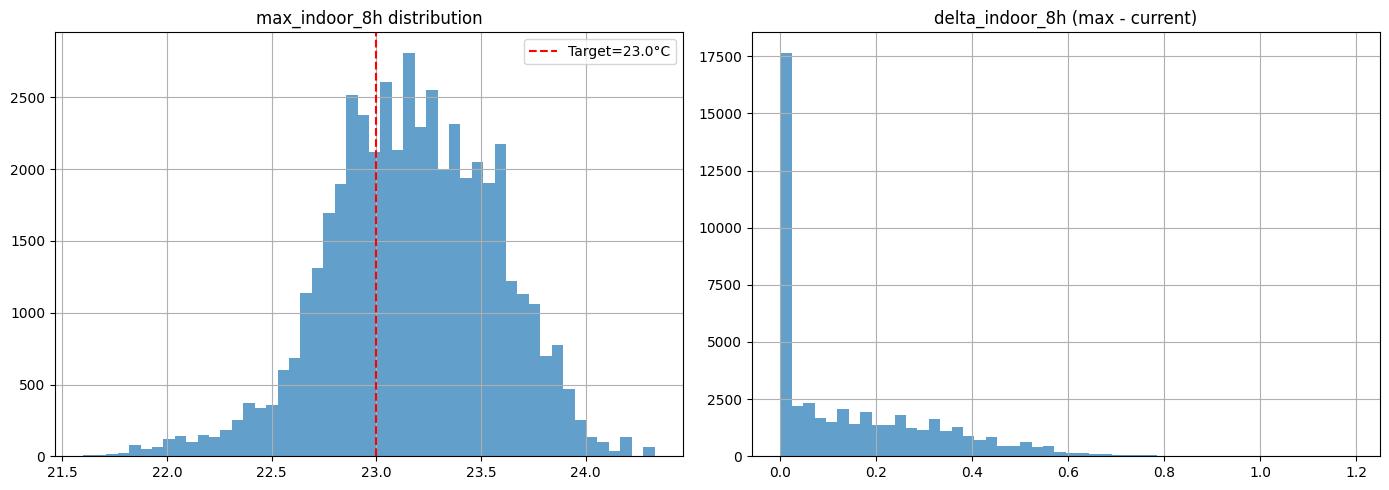

In [14]:
# Compute continuous regression label: max indoor temp in next 8h
# Use double-reversal rolling trick (same as calibration code)
label_steps = LABEL_HORIZON_H * SPH

_raw_max = (
    df['indoor_temp']
    .iloc[::-1]
    .rolling(label_steps, min_periods=label_steps)
    .max()
    .iloc[::-1]
)
df['max_indoor_8h'] = _raw_max

# Also residualized: delta = max_future - current
df['delta_indoor_8h'] = df['max_indoor_8h'] - df['indoor_temp']

# Drop rows where label is NaN (last 8h window)
df_reg = df[FEATURE_COLS_PRUNED + ['max_indoor_8h', 'delta_indoor_8h', 'label']].dropna().copy()
print(f'Regression dataset: {len(df_reg)} rows')
print(f'\nmax_indoor_8h stats:')
print(df_reg['max_indoor_8h'].describe().round(3))
print(f'\ndelta_indoor_8h stats:')
print(df_reg['delta_indoor_8h'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_reg['max_indoor_8h'].hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].axvline(COOLING_TARGET, color='r', ls='--', label=f'Target={COOLING_TARGET}°C')
axes[0].set_title('max_indoor_8h distribution')
axes[0].legend()

df_reg['delta_indoor_8h'].hist(bins=50, ax=axes[1], alpha=0.7)
axes[1].set_title('delta_indoor_8h (max - current)')
plt.tight_layout()
plt.show()

In [15]:
# Train regression model predicting delta_indoor_8h (residualized)
n_val_r = max(1, int(len(df_reg) * val_frac))
df_fit_r = df_reg.iloc[:-n_val_r]
df_val_r = df_reg.iloc[-n_val_r:]

X_fit_r = df_fit_r[FEATURE_COLS_PRUNED].values.astype(float)
y_fit_r = df_fit_r['delta_indoor_8h'].values
X_val_r = df_val_r[FEATURE_COLS_PRUNED].values.astype(float)
y_val_r = df_val_r['delta_indoor_8h'].values

reg_model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)
reg_model.fit(X_fit_r, y_fit_r)

y_pred_r = reg_model.predict(X_val_r)
from sklearn.metrics import mean_absolute_error, r2_score as r2_score_fn
mae_r = mean_absolute_error(y_val_r, y_pred_r)
r2_r = r2_score_fn(y_val_r, y_pred_r)

print(f'Regression Results (predicting delta_indoor_8h):')
print(f'  MAE: {mae_r:.4f}°C')
print(f'  R²:  {r2_r:.4f}')

# Convert regression to binary: predict overshoot when indoor + delta > target
indoor_val = df_val_r['indoor_temp'].values if 'indoor_temp' in df_val_r.columns else X_val_r[:, FEATURE_COLS_PRUNED.index('indoor_temp')]
predicted_max = indoor_val + y_pred_r
y_binary_true = df_val_r['label'].values.astype(int)

# Find threshold on predicted_max for F2 optimization
def find_f2_threshold_regression(y_true, predicted_max, target, n_points=200):
    margins = np.linspace(-2.0, 2.0, n_points)  # offset from target
    f2_scores = [fbeta_score(y_true, (predicted_max > (target + m)).astype(int), beta=2) 
                 for m in margins]
    best_idx = np.argmax(f2_scores)
    return target + margins[best_idx], f2_scores[best_idx]

reg_thresh, f2_reg = find_f2_threshold_regression(y_binary_true, predicted_max, COOLING_TARGET)
y_pred_reg_binary = (predicted_max > reg_thresh).astype(int)
auc_reg = roc_auc_score(y_binary_true, predicted_max)

print(f'\nRegression as classifier (threshold: predicted_max > {reg_thresh:.2f}°C):')
print(f'  AUC: {auc_reg:.4f}')
print(f'  F2:  {f2_reg:.4f}')
print(f'  Precision: {precision_score(y_binary_true, y_pred_reg_binary):.4f}')
print(f'  Recall: {recall_score(y_binary_true, y_pred_reg_binary):.4f}')

Regression Results (predicting delta_indoor_8h):
  MAE: 0.0887°C
  R²:  0.3637

Regression as classifier (threshold: predicted_max > 22.95°C):
  AUC: 0.9502
  F2:  0.9492
  Precision: 0.8779
  Recall: 0.9689


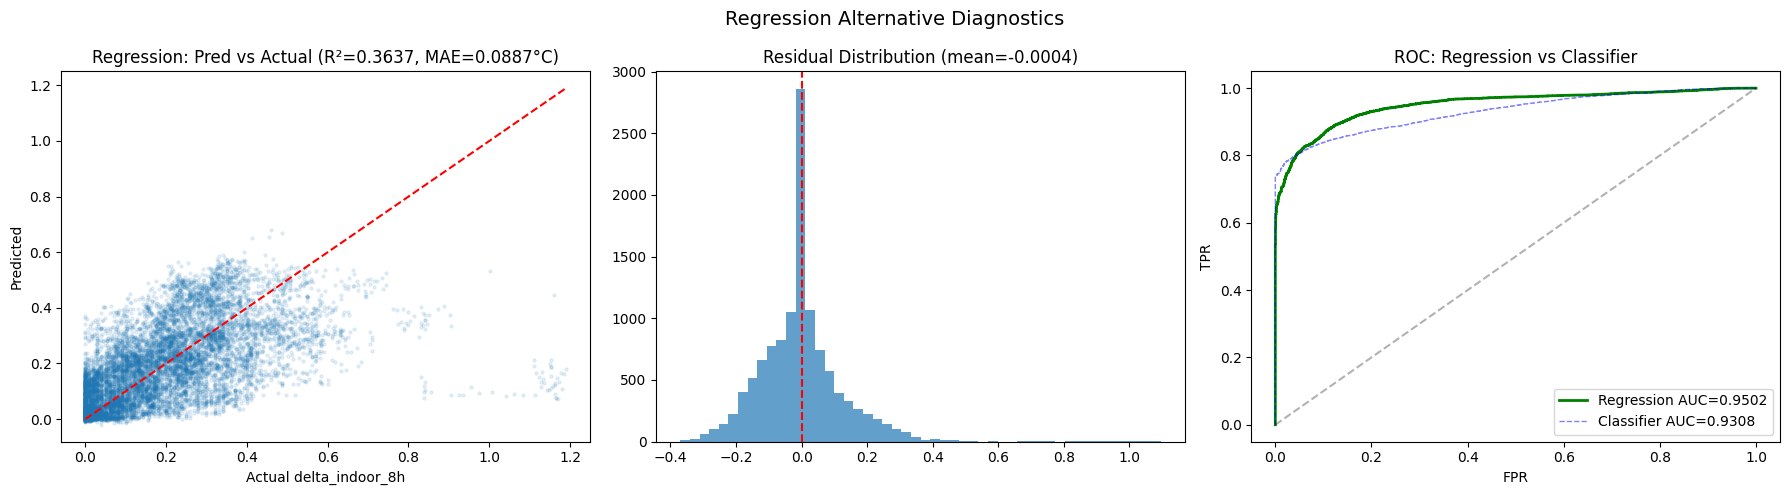

In [16]:
# Regression diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pred vs actual
axes[0].scatter(y_val_r, y_pred_r, alpha=0.1, s=5)
axes[0].plot([y_val_r.min(), y_val_r.max()], [y_val_r.min(), y_val_r.max()], 'r--')
axes[0].set_xlabel('Actual delta_indoor_8h')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Regression: Pred vs Actual (R²={r2_r:.4f}, MAE={mae_r:.4f}°C)')

# Residuals
residuals = y_val_r - y_pred_r
axes[1].hist(residuals, bins=50, alpha=0.7)
axes[1].axvline(0, color='r', ls='--')
axes[1].set_title(f'Residual Distribution (mean={residuals.mean():.4f})')

# Regression ROC as classifier
fpr_r, tpr_r, _ = roc_curve(y_binary_true, predicted_max)
axes[2].plot(fpr_r, tpr_r, 'g-', lw=2, label=f'Regression AUC={auc_reg:.4f}')
axes[2].plot(fpr, tpr, 'b--', lw=1, alpha=0.5, label=f'Classifier AUC={auc_base:.4f}')
axes[2].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC: Regression vs Classifier')
axes[2].legend()

plt.suptitle('Regression Alternative Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

## Section 7: Classifier vs Regressor Comparison

In [17]:
# Head-to-head comparison on same holdout
# Need to align datasets (regression has fewer rows due to NaN from rolling)
# Use the regression validation set indices as common ground
common_idx = df_val_r.index

# Re-predict classifier on same indices
X_common_cls = df.loc[common_idx, FEATURE_COLS_PRUNED].values.astype(float)
y_common = df.loc[common_idx, 'label'].values.astype(int)

y_proba_cls_common = enhanced_model.predict_proba(X_common_cls)[:, 1]
auc_cls_common = roc_auc_score(y_common, y_proba_cls_common)
_, f2_cls_common = find_f2_threshold(y_common, y_proba_cls_common)

print(f'=== HEAD-TO-HEAD COMPARISON (n={len(common_idx)}) ===')
print(f'{"Metric":<25s} {"Classifier":>12s} {"Regression":>12s} {"Winner":>10s}')
print(f'{"AUC":<25s} {auc_cls_common:12.4f} {auc_reg:12.4f} {"Reg" if auc_reg > auc_cls_common else "Cls":>10s}')
print(f'{"F2":<25s} {f2_cls_common:12.4f} {f2_reg:12.4f} {"Reg" if f2_reg > f2_cls_common else "Cls":>10s}')
print(f'{"MAE (regression)":<25s} {"—":>12s} {mae_r:12.4f}°C')
print(f'{"R² (regression)":<25s} {"—":>12s} {r2_r:12.4f}')

# Determine best approach
if auc_reg > auc_cls_common and f2_reg > f2_cls_common:
    best_approach = 'regression'
    print('\n✅ Regression wins on both AUC and F2')
elif auc_cls_common > auc_reg and f2_cls_common > f2_reg:
    best_approach = 'classifier'
    print('\n✅ Classifier wins on both AUC and F2')
else:
    # Mixed results — prefer F2 (recall-oriented for safety)
    best_approach = 'regression' if f2_reg > f2_cls_common else 'classifier'
    print(f'\n⚖️ Mixed results — choosing {best_approach} (F2 priority for safety)')

=== HEAD-TO-HEAD COMPARISON (n=11906) ===
Metric                      Classifier   Regression     Winner
AUC                             0.9438       0.9502        Reg
F2                              0.9425       0.9492        Reg
MAE (regression)                     —       0.0887°C
R² (regression)                      —       0.3637

✅ Regression wins on both AUC and F2


## Section 8: Optuna HPO (on best approach)

In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use 3-fold time-series CV for hyperparameter tuning
tscv = TimeSeriesSplit(n_splits=3)

if best_approach == 'classifier':
    X_opt = df_clean[FEATURE_COLS_PRUNED].values.astype(float)
    y_opt = df_clean['label'].values.astype(int)
    
    def objective(trial):
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42,
            'verbose': -1,
        }
        scores = []
        for train_idx, val_idx in tscv.split(X_opt):
            m = lgb.LGBMClassifier(**params)
            m.fit(X_opt[train_idx], y_opt[train_idx])
            p = m.predict_proba(X_opt[val_idx])[:, 1]
            scores.append(roc_auc_score(y_opt[val_idx], p))
        return np.mean(scores)
else:
    X_opt = df_reg[FEATURE_COLS_PRUNED].values.astype(float)
    y_opt_delta = df_reg['delta_indoor_8h'].values
    y_opt_label = df_reg['label'].values.astype(int)
    indoor_opt = df_reg['indoor_temp'].values if 'indoor_temp' in df_reg.columns else X_opt[:, FEATURE_COLS_PRUNED.index('indoor_temp')]
    
    def objective(trial):
        params = {
            'objective': 'regression_l1',
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42,
            'verbose': -1,
        }
        scores = []
        for train_idx, val_idx in tscv.split(X_opt):
            m = lgb.LGBMRegressor(**params)
            m.fit(X_opt[train_idx], y_opt_delta[train_idx])
            pred = m.predict(X_opt[val_idx])
            pred_max = indoor_opt[val_idx] + pred
            scores.append(roc_auc_score(y_opt_label[val_idx], pred_max))
        return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest trial: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0.9739
Best params: {'n_estimators': 203, 'learning_rate': 0.01233988833863314, 'max_depth': 8, 'num_leaves': 29, 'min_child_samples': 48, 'reg_alpha': 3.1804670374703212, 'reg_lambda': 0.0006854022491321795, 'subsample': 0.8264869879116047, 'colsample_bytree': 0.8997100547813792}


In [19]:
# Train final model with Optuna params, compare with pre-Optuna
best_params = study.best_params.copy()

if best_approach == 'classifier':
    best_params.update({'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'verbose': -1})
    optuna_model = lgb.LGBMClassifier(**best_params)
    optuna_model.fit(X_fit_e, y_fit_e)
    y_proba_opt = optuna_model.predict_proba(X_val_e)[:, 1]
    auc_opt = roc_auc_score(y_val_e, y_proba_opt)
    thresh_opt, f2_opt = find_f2_threshold(y_val_e, y_proba_opt)
    
    # Holdout guard: keep pre-Optuna if Optuna is worse
    pre_optuna_auc = current_auc
    if auc_opt > pre_optuna_auc:
        print(f'✅ Optuna BETTER: AUC {pre_optuna_auc:.4f} → {auc_opt:.4f} (+{auc_opt-pre_optuna_auc:.4f})')
        print(f'   F2: {f2_pruned:.4f} → {f2_opt:.4f}')
        final_model = optuna_model
        final_auc = auc_opt
        final_f2 = f2_opt
        final_thresh = thresh_opt
        final_params = best_params
    else:
        print(f'⚠️ Optuna WORSE on holdout: AUC {pre_optuna_auc:.4f} → {auc_opt:.4f}')
        print(f'   Keeping pre-Optuna model')
        final_model = enhanced_model
        final_auc = pre_optuna_auc
        final_f2 = f2_pruned
        final_thresh = thresh_pruned
        final_params = lgb_params
else:
    best_params.update({'objective': 'regression_l1', 'random_state': 42, 'verbose': -1})
    optuna_model = lgb.LGBMRegressor(**best_params)
    optuna_model.fit(X_fit_r, y_fit_r)
    y_pred_opt = optuna_model.predict(X_val_r)
    pred_max_opt = indoor_val + y_pred_opt
    auc_opt = roc_auc_score(y_binary_true, pred_max_opt)
    mae_opt = mean_absolute_error(y_val_r, y_pred_opt)
    r2_opt = r2_score_fn(y_val_r, y_pred_opt)
    
    if auc_opt > auc_reg:
        print(f'✅ Optuna BETTER: AUC {auc_reg:.4f} → {auc_opt:.4f}, MAE {mae_r:.4f} → {mae_opt:.4f}')
        final_model = optuna_model
        final_auc = auc_opt
        final_params = best_params
        reg_thresh_opt, f2_opt = find_f2_threshold_regression(y_binary_true, pred_max_opt, COOLING_TARGET)
        final_f2 = f2_opt
        final_thresh = reg_thresh_opt
    else:
        print(f'⚠️ Optuna WORSE: AUC {auc_reg:.4f} → {auc_opt:.4f}. Keeping pre-Optuna.')
        final_model = reg_model
        final_auc = auc_reg
        final_f2 = f2_reg
        final_thresh = reg_thresh
        final_params = {'objective': 'regression_l1', 'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6}

✅ Optuna BETTER: AUC 0.9502 → 0.9582, MAE 0.0887 → 0.0827


## Section 9: Threshold Sensitivity Analysis

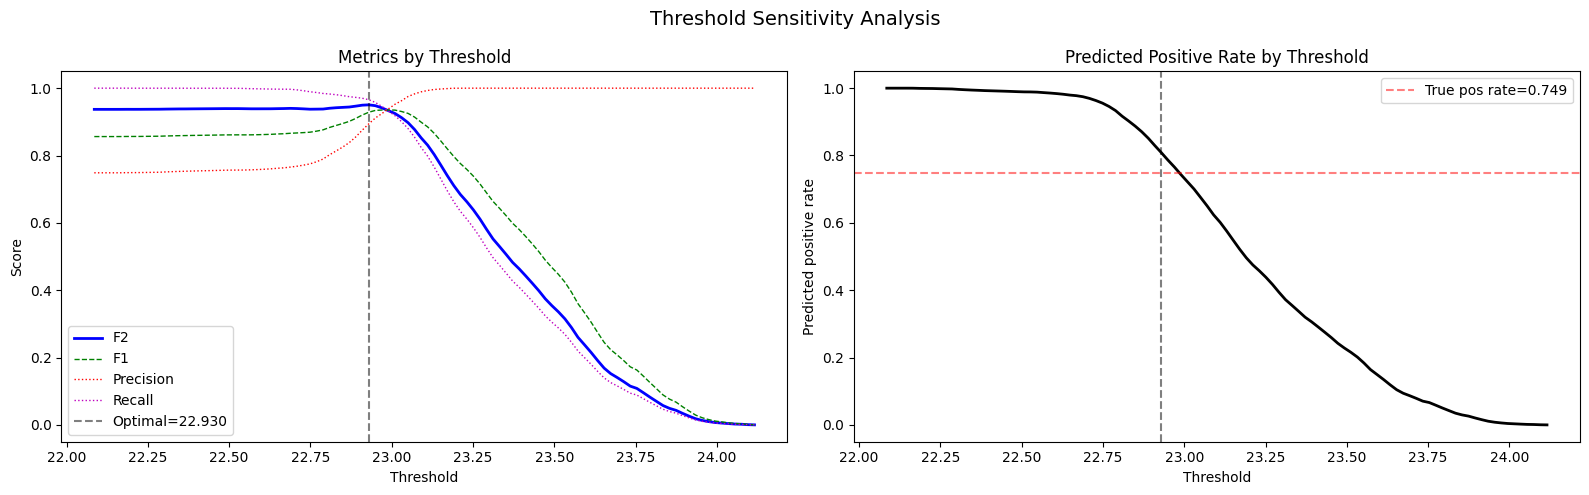

Current threshold: 0.0346 → positive rate = 100.0%
Optimal threshold: 22.9296 → positive rate = 80.8%
True positive rate: 74.9%


In [20]:
# Threshold sensitivity analysis
if best_approach == 'classifier':
    y_proba_final = final_model.predict_proba(
        df_val_e[FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
    y_true_final = y_val_e
    thresholds = np.linspace(0.01, 0.99, 200)
else:
    y_proba_final = indoor_val + final_model.predict(X_val_r)
    y_true_final = y_binary_true
    thresholds = np.linspace(COOLING_TARGET - 2, COOLING_TARGET + 2, 200)

metrics_by_thresh = []
for t in thresholds:
    y_p = (y_proba_final >= t).astype(int)
    if y_p.sum() == 0 or y_p.sum() == len(y_p):
        continue
    metrics_by_thresh.append({
        'threshold': t,
        'f2': fbeta_score(y_true_final, y_p, beta=2),
        'f1': f1_score(y_true_final, y_p),
        'precision': precision_score(y_true_final, y_p),
        'recall': recall_score(y_true_final, y_p),
        'positive_rate': y_p.mean(),
    })

thresh_df = pd.DataFrame(metrics_by_thresh)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['f2'], 'b-', lw=2, label='F2')
axes[0].plot(thresh_df['threshold'], thresh_df['f1'], 'g--', lw=1, label='F1')
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], 'r:', lw=1, label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], 'm:', lw=1, label='Recall')
axes[0].axvline(final_thresh, color='k', ls='--', alpha=0.5, label=f'Optimal={final_thresh:.3f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics by Threshold')
axes[0].legend()

axes[1].plot(thresh_df['threshold'], thresh_df['positive_rate'], 'k-', lw=2)
axes[1].axhline(y_true_final.mean(), color='r', ls='--', alpha=0.5, label=f'True pos rate={y_true_final.mean():.3f}')
axes[1].axvline(final_thresh, color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Predicted positive rate')
axes[1].set_title('Predicted Positive Rate by Threshold')
axes[1].legend()

plt.suptitle('Threshold Sensitivity Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Current threshold analysis
print(f'Current threshold: {meta["threshold"]:.4f} → positive rate = '
      f'{(y_proba_final >= meta["threshold"]).mean():.1%}')
print(f'Optimal threshold: {final_thresh:.4f} → positive rate = '
      f'{(y_proba_final >= final_thresh).mean():.1%}')
print(f'True positive rate: {y_true_final.mean():.1%}')

## Section 10: Summary

In [21]:
# Final summary table
print('=' * 70)
print('COOLING ML MODEL ANALYSIS — FINAL SUMMARY')
print('=' * 70)
print(f'\n{"Stage":<30s} {"AUC":>8s} {"F2":>8s} {"Features":>10s} {"Threshold":>10s}')
print('-' * 70)
print(f'{"Baseline (production)":<30s} {meta["roc_auc"]:8.4f} {meta["val_f2"]:8.4f} {meta["n_features"]:10d} {meta["threshold"]:10.4f}')
print(f'{"Baseline (reproduced)":<30s} {auc_base:8.4f} {f2_base:8.4f} {len(FEATURE_COLS_BASELINE):10d} {thresh_base:10.4f}')
print(f'{"Enhanced (+17 features)":<30s} {auc_enh:8.4f} {f2_enh:8.4f} {len(FEATURE_COLS_ENHANCED):10d} {thresh_enh:10.4f}')
print(f'{"After pruning":<30s} {current_auc:8.4f} {f2_pruned:8.4f} {len(FEATURE_COLS_PRUNED):10d} {thresh_pruned:10.4f}')
print(f'{"Regression alternative":<30s} {auc_reg:8.4f} {f2_reg:8.4f} {len(FEATURE_COLS_PRUNED):10d} {"—":>10s}')
print(f'{"Final (Optuna-tuned)":<30s} {final_auc:8.4f} {final_f2:8.4f} {len(FEATURE_COLS_PRUNED):10d} {final_thresh:10.4f}')
print('-' * 70)
print(f'\nBest approach: {best_approach.upper()}')
print(f'AUC improvement: {meta["roc_auc"]:.4f} → {final_auc:.4f} ({final_auc - meta["roc_auc"]:+.4f})')
print(f'F2 improvement:  {meta["val_f2"]:.4f} → {final_f2:.4f} ({final_f2 - meta["val_f2"]:+.4f})')
print(f'Features: {meta["n_features"]} → {len(FEATURE_COLS_PRUNED)}')

# Dropped features
dropped = [f for f in FEATURE_COLS_ENHANCED if f not in FEATURE_COLS_PRUNED]
if dropped:
    print(f'\nDropped during pruning ({len(dropped)}): {dropped}')

# New features that survived pruning
new_kept = [f for f in NEW_FEATURES if f in FEATURE_COLS_PRUNED]
print(f'\nNew features kept ({len(new_kept)}/{len(NEW_FEATURES)}): {new_kept}')

print(f'\n⚠️  Note: wind_speed, fireplace_on, tv_on, living_room_temp are NOT in the existing CSV.')
print(f'    After re-running calibration with expanded HA fetch, these 6+ additional features')
print(f'    will be available. Re-run this notebook with the new training data to measure')
print(f'    the full improvement from all 23 new features.')

COOLING ML MODEL ANALYSIS — FINAL SUMMARY

Stage                               AUC       F2   Features  Threshold
----------------------------------------------------------------------
Baseline (production)            0.9710   0.9427         47     0.0346
Baseline (reproduced)            0.9308   0.9425         47     0.0100
Enhanced (+17 features)          0.9419   0.9425         64     0.0100
After pruning                    0.9431   0.9424         61     0.0100
Regression alternative           0.9502   0.9492         61          —
Final (Optuna-tuned)             0.9582   0.9505         61    22.9296
----------------------------------------------------------------------

Best approach: REGRESSION
AUC improvement: 0.9710 → 0.9582 (-0.0128)
F2 improvement:  0.9427 → 0.9505 (+0.0078)
Features: 47 → 61

Dropped during pruning (3): ['AT_roh_4h', 'pv_forecast_9h', 'outlet_indoor_diff']

New features kept (17/17): ['heat_loss_driving_force', 'indoor_temp_gradient', 'indoor_margin_rate', 'd